In [2]:
from google.colab import files
uploaded = files.upload()



Saving archive.zip to archive.zip


In [4]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [5]:
import os
print(os.listdir())

['.config', 'cardekho-used-car-price-prediction.ipynb', 'cardekho_dataset.csv', 'archive.zip', 'sample_data']


In [6]:
import pandas as pd

data = pd.read_csv("cardekho_dataset.csv")
data.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [7]:
print(data.columns)
print(data.info())

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  fl

In [8]:
data = data.drop(['Unnamed: 0', 'car_name'], axis=1)

In [9]:
data = data.dropna()

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [12]:
def price_category(price):
    if price < 300000:
        return 0   # Low
    elif price < 800000:
        return 1   # Medium
    else:
        return 2   # High

data['price_category'] = data['selling_price'].apply(price_category)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_reg = data.drop(['selling_price', 'price_category'], axis=1)
y_reg = data['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

model_reg = LinearRegression()
model_reg.fit(X_train, y_train)

y_pred_reg = model_reg.predict(X_test)

print("Regression MSE:", mean_squared_error(y_test, y_pred_reg))

Regression MSE: 253518909949.75528


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_clf = data.drop(['selling_price', 'price_category'], axis=1)
y_clf = data['price_category']

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

model_clf = LogisticRegression(max_iter=1000)
model_clf.fit(X_train, y_train)

y_pred_clf = model_clf.predict(X_test)

print("Classification Accuracy:", accuracy_score(y_test, y_pred_clf))

Classification Accuracy: 0.7693804735647097


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
import matplotlib.pyplot as plt

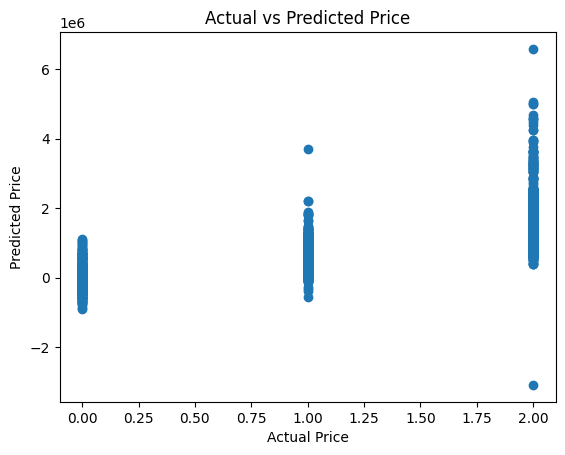

In [17]:
plt.scatter(y_test, y_pred_reg)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()